In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

The dataset used can be obtained from https://www.kaggle.com/datasets/jarredpriester/taylor-swift-spotify-dataset/ (last accessed 13/07/2026).

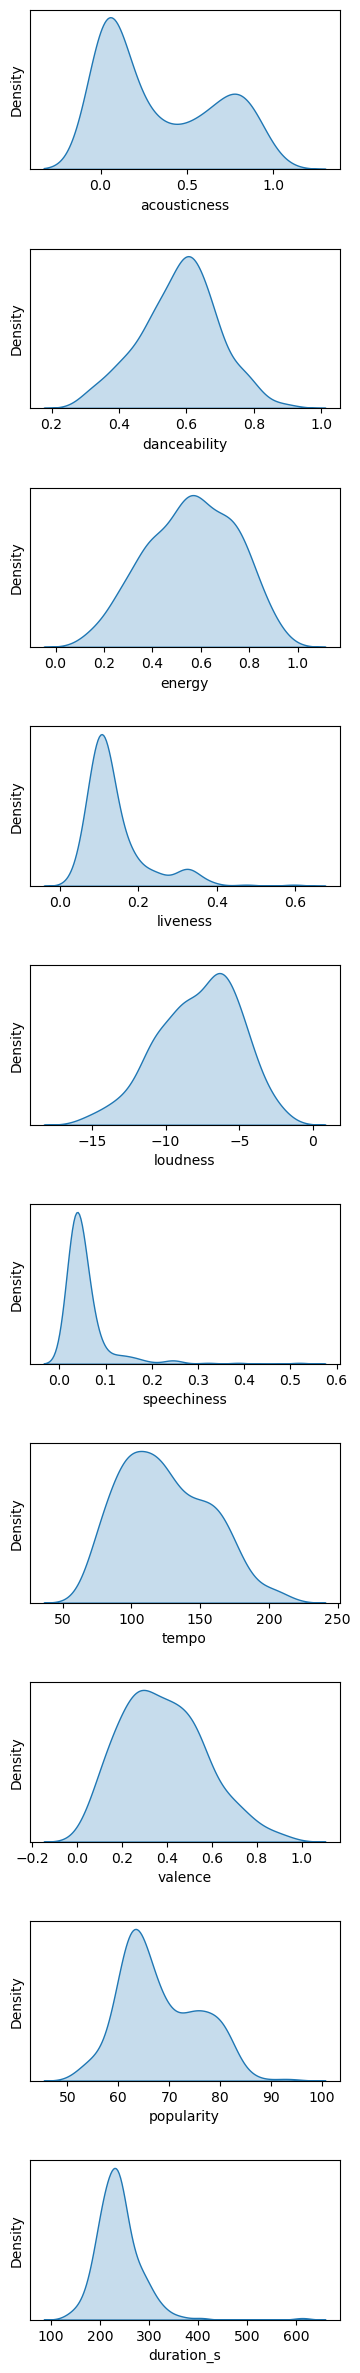

In [2]:
path = 'audio_features.csv'
df = pd.read_csv(path)

# the non-duplicate tracks where I have lyric data
df = df[df['album'].isin([
    'THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY',
    "1989 (Taylor's Version) [Deluxe]",
    "Speak Now (Taylor's Version)", 
    'Midnights (The Til Dawn Edition)',
    "Red (Taylor's Version)",
    "Fearless (Taylor's Version)", 
    'evermore (deluxe version)',
    'folklore (deluxe version)',
    'Lover', 
    'reputation',
    'Taylor Swift (Deluxe Edition)'
])]

# drop voice memo tracks
df = df[~df['name'].str.endswith('Voice Memo')]

# retain the names for later
names = df.pop('name')
albums = df.pop('album')

# extract the musical features
df = df[[
    'acousticness',
    'danceability',
    'energy',
    'liveness', 
    'loudness', 
    'speechiness', 
    'tempo', 
    'valence',
    'duration_ms',
    'popularity'
]]

# convert duration to seconds
df['duration_s'] = (df['duration_ms']/1000).round(decimals=0)
df = df.drop('duration_ms', axis=1)

# plot the distribution of musical features
fig, ax = plt.subplots(nrows=10, figsize=(4, 30))
plt.subplots_adjust(hspace=0.5)

for i, column in enumerate(df.columns):
    sns.kdeplot(x=df[column], ax=ax[i], fill=True)
    ax[i].set_yticks([])

plt.show()

Skew features should be transformed to reduce the influence of extreme values.

In [3]:
skewness = df.skew(numeric_only=True)
skewness[abs(skewness)>1]

liveness       2.189533
speechiness    4.477641
duration_s     2.535450
dtype: float64

Features should be checked for strong correlations.

<Axes: >

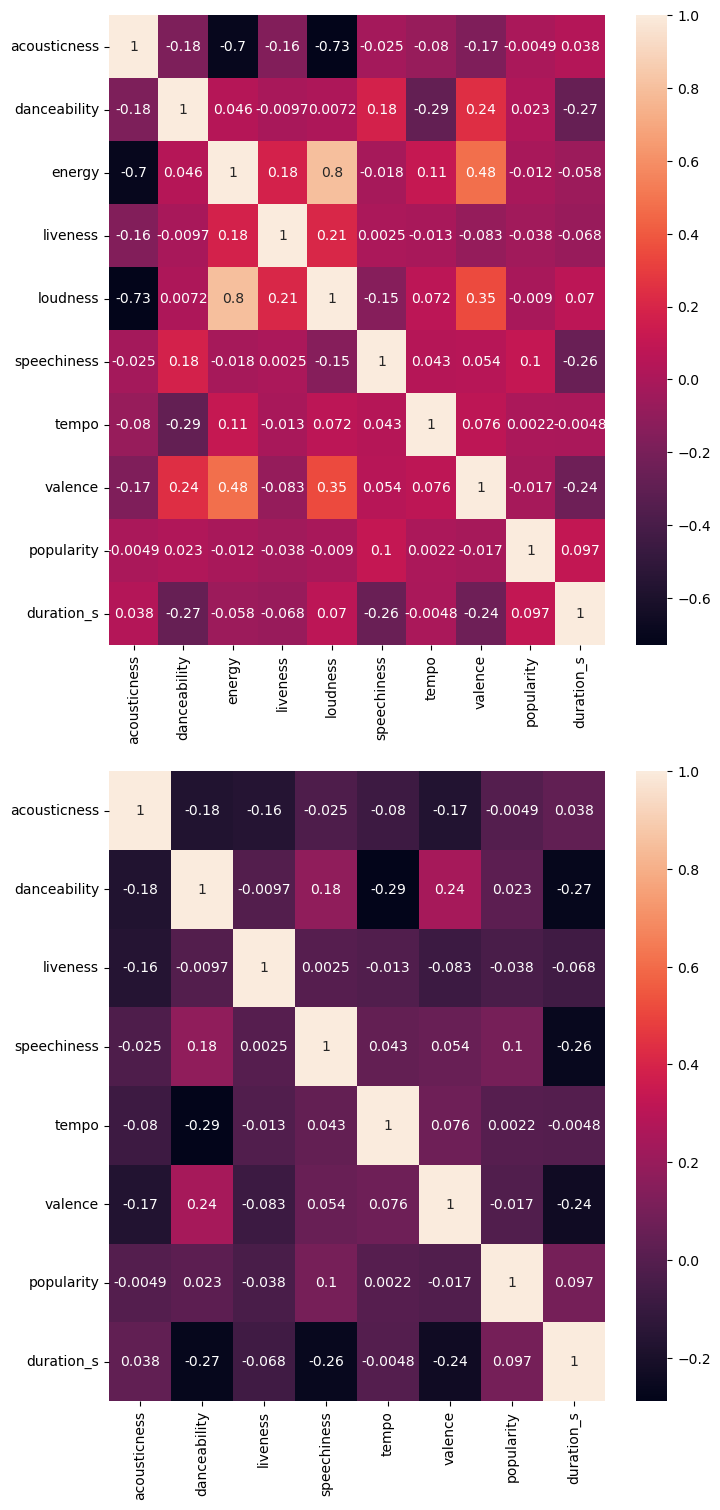

In [4]:
fig, ax = plt.subplots(nrows=2, figsize=(8, 18))

sns.heatmap(df.corr(), annot=True, ax=ax[0])
sns.heatmap(df.drop(['loudness', 'energy'], axis=1).corr(), annot=True, ax=ax[1])

Removing loudness and energy removes strong correlations between features.

A preprocessing pipeline can be created to transform the data.

In [5]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(transform_output='pandas')

df = df.drop(['loudness', 'energy'], axis=1)
pt = PowerTransformer(method="yeo-johnson")

yj_transform = ColumnTransformer([
    ('right_skewed', pt, ['liveness', 'speechiness', 'duration_s'])
], remainder='passthrough')

preprocessor = Pipeline([
    ('skew_fixer', yj_transform),
    ('scaler', StandardScaler())
])

X = preprocessor.fit_transform(df)

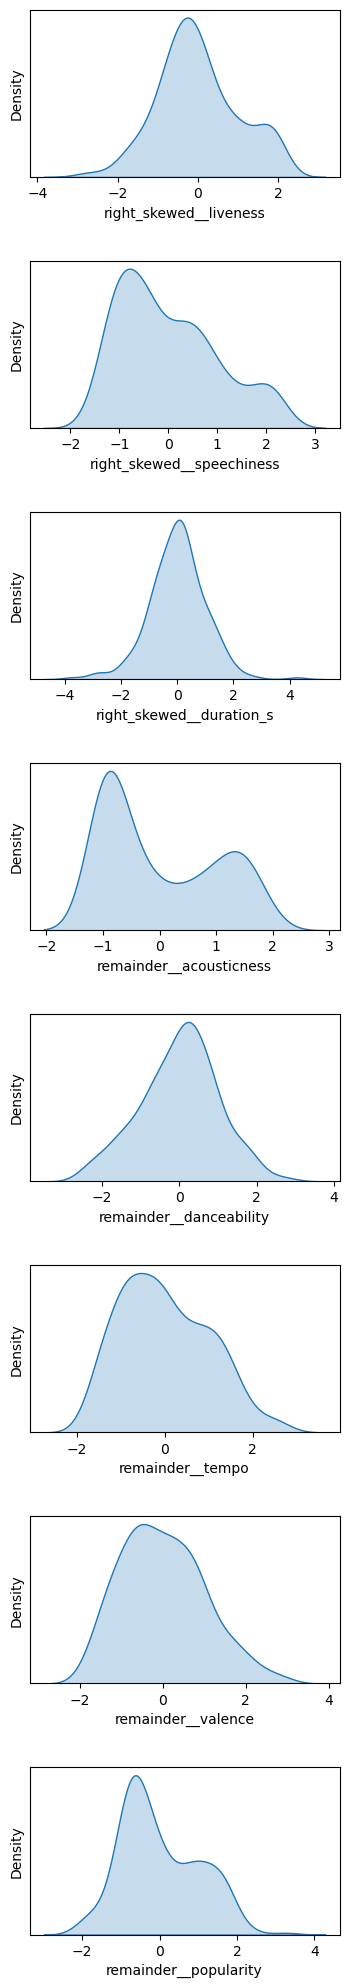

In [6]:
# plot the distribution of musical features after transformation
fig, ax = plt.subplots(nrows=8, figsize=(4, 25))
plt.subplots_adjust(hspace=0.5)

for i, column in enumerate(X.columns):
    sns.kdeplot(x=X[column], ax=ax[i], fill=True)
    ax[i].set_yticks([])

plt.show()

In [7]:
X['name'] = names
X['album'] = albums
X.to_csv('audio_features_transformed.csv')